# Volcanic Eruptions

Exploring data from the VOGRIPA (Volcano Global Risk Identification and Analysis Project) database.

Allen Downey
[MIT License](https://mit-license.org/)

In [24]:
# Install empiricaldist if we don't already have it

try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

In [25]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download(
    "https://github.com/AllenDowney/ProbablyOverthinkingIt/raw/book/notebooks/utils.py"
)


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate

## Data Loading and Cleaning

Load the VOGRIPA data file.

In [27]:
# Read the CSV file (using latin-1 encoding to handle special characters)
df = pd.read_csv("VOGRIPA_Version3_Data_Export.csv", encoding="latin-1")
df.shape

(2310, 109)

Inspect the column names and data types.

In [28]:
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print("\nColumn names:")
print(df.columns.tolist()[:20])  # Show first 20 columns

Total rows: 2310
Total columns: 109

Column names:
['Volcano_Name', 'Vnum', 'Latitude', 'Longitude', 'Region', 'Sub_Region', 'Volcano_Type', 'Unit_Name', 'Eruption_Start_Day', 'Eruption_Start_Month', 'Eruption_Start_Year', 'Year_BP', 'Year_BP_Error', 'Dating_Technique', 'Quality', 'Alternative_Values', 'Tephra_Fall_Deposit_Volume', 'Qualifier', 'Alternate_Values', 'Derivation']


Check the key columns for analysis.

In [29]:
# Key columns for magnitude analysis
print("Maximum_VEI:")
print(df["Maximum_VEI"].describe())
print(f"\nNon-null count: {df['Maximum_VEI'].notna().sum()} / {len(df)}")

Maximum_VEI:
count    2282.000000
mean        4.875548
std         1.008220
min         2.000000
25%         4.000000
50%         5.000000
75%         5.000000
max         8.000000
Name: Maximum_VEI, dtype: float64

Non-null count: 2282 / 2310


In [30]:
print("\nMagnitude:")
print(df["Magnitude"].describe())
print(f"\nNon-null count: {df['Magnitude'].notna().sum()} / {len(df)}")


Magnitude:
count    2310.000000
mean        5.190632
std         1.015540
min         3.600000
25%         4.300000
50%         5.000000
75%         5.900000
max         9.100000
Name: Magnitude, dtype: float64

Non-null count: 2310 / 2310


Check the distribution of VEI values.

In [31]:
print("VEI value counts:")
print(df["Maximum_VEI"].value_counts().sort_index())

VEI value counts:
Maximum_VEI
2.0      2
3.0     30
4.0    972
5.0    739
6.0    354
7.0    155
8.0     30
Name: count, dtype: int64


Extract the magnitude data. We'll use `Magnitude` as the primary variable since it's continuous and 100% complete.

In [32]:
# Extract magnitude values
mags = df["Magnitude"].dropna()
mags.describe()

count    2310.000000
mean        5.190632
std         1.015540
min         3.600000
25%         4.300000
50%         5.000000
75%         5.900000
max         9.100000
Name: Magnitude, dtype: float64

Compute the tail distribution (fraction of values >= x for all x).

In [33]:
from empiricaldist import Pmf, Surv


def make_surv(seq):
    """Make a non-standard survival function, P(X>=x)"""
    pmf = Pmf.from_seq(seq)
    surv = pmf.make_surv() + pmf

    # correct for numerical error
    surv.iloc[0] = 1
    return Surv(surv)

In [34]:
surv = make_surv(mags)

In [35]:
xlabel = "Magnitude"
ylabel = "Prob >= $x$"

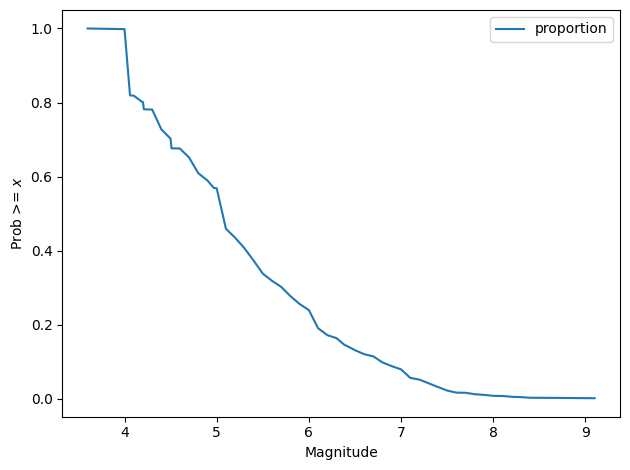

In [36]:
surv.plot()

decorate(xlabel=xlabel, ylabel=ylabel)

## Fit a Gaussian

Find the Gaussian that best matches percentiles with the data.

In [37]:
from empiricaldist import Pmf
from scipy.stats import norm


def truncated_normal_sf(qs, mu, sigma):
    ps = norm.sf(qs, mu, sigma)
    surv_model = Surv(ps / ps[0], qs)
    return surv_model

In [40]:
from scipy.optimize import least_squares


def fit_truncated_normal(surv):
    low, high = surv.qs.min(), surv.qs.max()
    qs_model = np.linspace(low, high, 1000)

    # match 20 percentiles from 1st to 99th
    ps = np.linspace(0.1, 0.99, 20)
    qs = surv.inverse(ps)

    def error_func(params):
        mu, sigma = params

        sf_model = truncated_normal_sf(qs_model, mu, sigma)
        error = surv(qs) - sf_model(qs)
        return error

    params = 5, 1
    res = least_squares(error_func, x0=params, xtol=1e-3)
    assert res.success
    return res.x

In [41]:
mu, sigma = fit_truncated_normal(surv)
mu, sigma

(4.425084493486837, 1.5767346384940568)

In [42]:
low, high = surv.qs.min(), surv.qs.max()
qs = np.linspace(low, high, 2000)
surv_model = truncated_normal_sf(qs, mu, sigma)

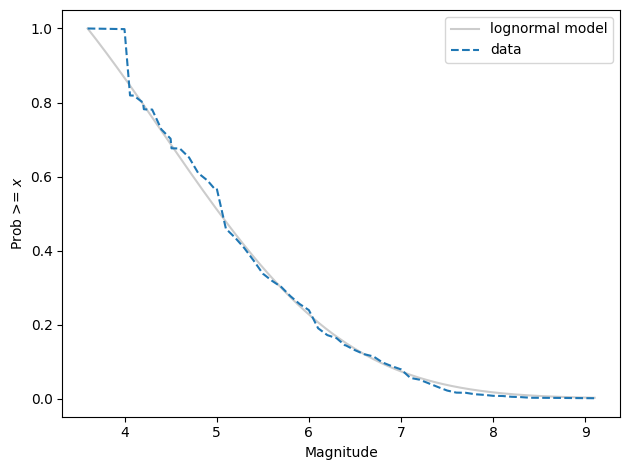

In [43]:
surv_model.plot(color="gray", alpha=0.4, label="lognormal model")
surv.plot(ls="--", label="data")

decorate(xlabel=xlabel, ylabel=ylabel)
plt.savefig("volcano1.png", dpi=300)

Plot results with error bounds.

In [44]:
from scipy.stats import binom
from utils import underride


def empirical_error_bounds(surv, n, qs, alpha=0.95):
    """Find the bounds on a normal CDF analytically."""
    # find the correct probabilities
    ps = surv.make_cdf()(qs)

    # find the upper and lower percentiles of
    # a binomial distribution
    p_low = (1 - alpha) / 2
    p_high = 1 - p_low

    low = binom.ppf(p_low, n, ps) / n
    low[ps == 1] = 1
    high = binom.ppf(p_high, n, ps) / n
    return 1 - low, 1 - high

In [45]:
def plot_error_bounds(surv, n, **options):
    underride(options, linewidth=0, alpha=0.1, capstyle="round")
    qs = np.linspace(surv.qs.min(), surv.qs.max(), 100)
    low, high = empirical_error_bounds(surv, n, qs)

    plt.fill_between(qs, low, high, **options)

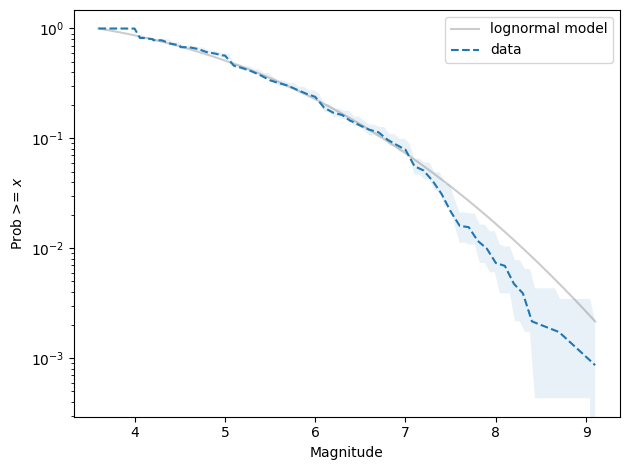

In [46]:
surv_model.plot(color="gray", alpha=0.4, label="lognormal model")
surv.plot(ls="--", label="data")

plot_error_bounds(surv, mags.count(), color="C0")

decorate(xlabel=xlabel, ylabel=ylabel, yscale="log")
plt.savefig("volcano2.png", dpi=300)

The error bound extends to negative infinity, which means that at this sample size, it was plausible we would not have seen an eruption above a certain magnitude.

Evaluating the empirical survival function and the model at an extreme magnitude.

In [47]:
surv(9), surv_model(9)

(array(0.0017316), array(0.00266377))

## Fit a Student t

Find the df parameter that best matches the tail, then the mu and sigma parameters that best match the percentiles.

In [48]:
from scipy.stats import t as t_dist


def truncated_t_sf(qs, df, mu, sigma):
    ps = t_dist.sf(qs, df, mu, sigma)
    surv_model = Surv(ps / ps[0], qs)
    return surv_model

In [50]:
from scipy.optimize import least_squares


def fit_truncated_t(df, surv):
    """Given df, find the best values of mu and sigma."""
    low, high = surv.qs.min(), surv.qs.max()
    qs_model = np.linspace(low, high, 1000)

    # match 20 percentiles from 1st to 99th
    ps = np.linspace(0.01, 0.9, 20)
    qs = surv.inverse(ps)

    def error_func_t(params, df, surv):
        mu, sigma = params
        surv_model = truncated_t_sf(qs_model, df, mu, sigma)

        error = surv(qs) - surv_model(qs)
        return error

    params = 5, 1
    res = least_squares(error_func_t, x0=params, args=(df, surv), xtol=1e-3)
    assert res.success
    return res.x

In [51]:
from scipy.optimize import minimize


def minimize_df(df0, surv, bounds=[(1, 1e6)], ps=None):
    low, high = surv.qs.min(), surv.qs.max()
    qs_model = np.linspace(low, high * 1.0, 2000)

    if ps is None:
        t = surv.ps[0], surv.ps[-2]
        t = 0.1, surv.ps[-2]
        low, high = np.log10(t)
        ps = np.logspace(low, high, 30, endpoint=False)

    qs = surv.inverse(ps)

    def error_func_tail(params):
        (df,) = params
        mu, sigma = fit_truncated_t(df, surv)
        surv_model = truncated_t_sf(qs_model, df, mu, sigma)

        errors = np.log10(surv(qs)) - np.log10(surv_model(qs))
        return np.sum(errors**2)

    params = (df0,)
    res = minimize(error_func_tail, x0=params, bounds=bounds, tol=1e-3, method="Powell")
    assert res.success
    return res.x

Search for the value of df that best matches the tail behavior.

In [52]:
df = minimize_df(5, surv, [(1, 1000)])
df

array([999.98434748])

Given that value of df, find mu and sigma to best match percentiles.

In [53]:
mu, sigma = fit_truncated_t(df, surv)
df, mu, sigma

(array([999.98434748]), 4.518881454156973, 1.5027097987797056)

Run the model out to a higher magnitude.

In [54]:
# low, high = surv.qs.min(), surv.qs.max()
low, high = surv.qs.min(), 10
qs = np.linspace(low, high, 2000)
surv_model = truncated_t_sf(qs, df, mu, sigma)

On a linear scale, the model looks pretty good.

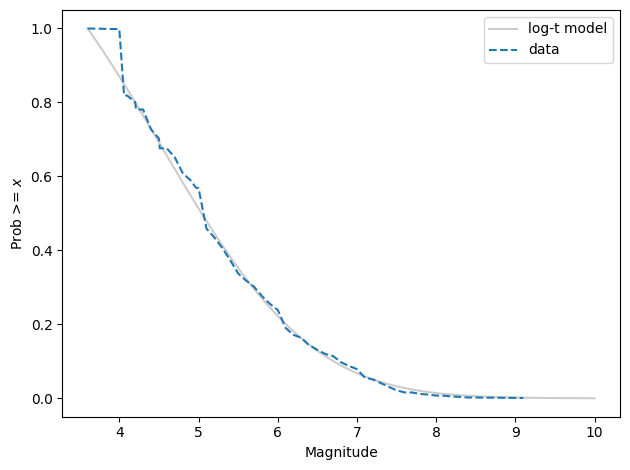

In [55]:
surv_model.plot(color="gray", alpha=0.4, label="log-t model")
surv.plot(ls="--", label="data")

decorate(xlabel=xlabel, ylabel=ylabel)
plt.savefig("volcano3.png", dpi=300)

On a log scale we can see that it matches the tail behavior much better than the Gaussian model.

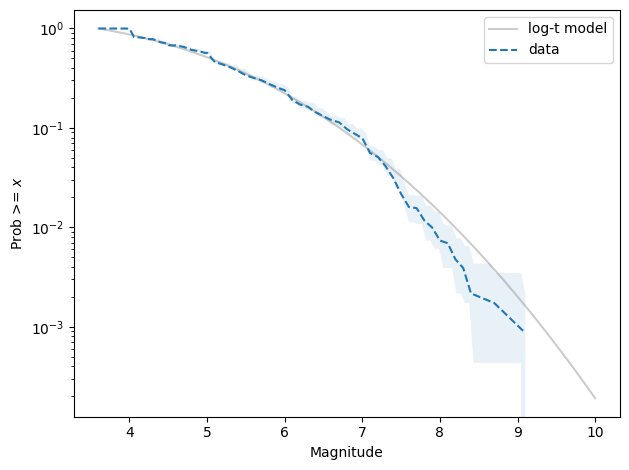

In [56]:
surv_model.plot(color="gray", alpha=0.4, label="log-t model")
surv.plot(ls="--", label="data")

plot_error_bounds(surv, mags.count(), color="C0")

decorate(xlabel=xlabel, ylabel=ylabel, yscale="log")
plt.savefig("volcano4.png", dpi=300)